<a href="https://colab.research.google.com/github/KingsleyCE9/Project-1/blob/main/MScFE_642_Deep_Learning_for_Finance_Group_Work_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MScFE 642 - Deep Learning for Finance

Group Work Project : 3


Student Group 13610

Peter Njogu Thuita

Lennox Thompson

Kingsley Chiedozie Ezekwe





23/03/2026

Install Libraries

In [2]:
!pip install yfinance pyts tensorflow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.6 MB/s eta 0:00:00


Import Libraries

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv2D, Flatten

Step 1a - Data Collection and Description

In [4]:
data = yf.download("BTC-USD", start="2018-01-01", end="2024-01-01")

# limit to < 2000 observations
data = data.tail(1800)

data["Returns"] = data["Close"].pct_change()
data = data.dropna()

print("Number of observations:", len(data))
data.head()

/tmp/ipykernel_10351/2528415486.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Number of observations: 1799


Price,Close,High,Low,Open,Volume,Returns
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
Date,,,,,,
2019-01-28,3470.450439,3586.750977,3439.232910,3584.283203,6908930483,-0.031673
2019-01-29,3448.116943,3476.065430,3400.819824,3468.870117,5897159493,-0.006435
2019-01-30,3486.181641,3495.174805,3429.387939,3443.896973,5955112627,0.011039
2019-01-31,3457.792725,3504.804932,3447.915771,3485.409180,5831198271,-0.008143
2019-02-01,3487.945312,3501.954102,3431.591553,3460.547119,5422926707,0.008720


Graph - Price Series

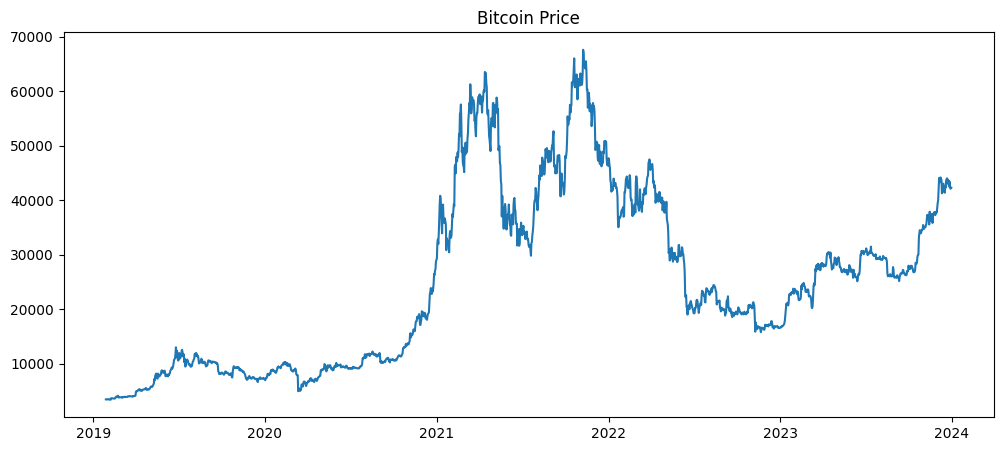

In [5]:
plt.figure(figsize=(12,5))
plt.plot(data["Close"])
plt.title("Bitcoin Price")
plt.show()

Graph - Returns Series

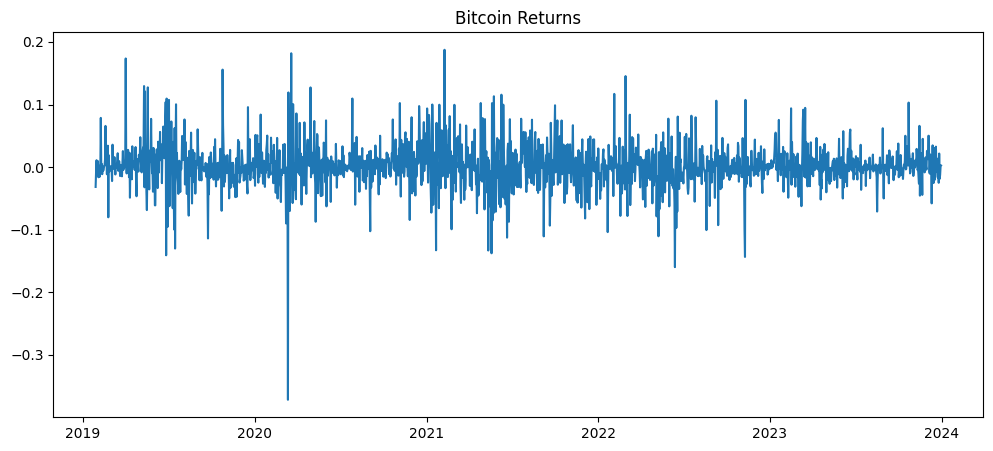

In [6]:
plt.figure(figsize=(12,5))
plt.plot(data["Returns"])
plt.title("Bitcoin Returns")
plt.show()

Step 1b - Create Features and Labels (with leakage)

In [7]:
for i in range(1,6):
    data[f"lag_{i}"] = data["Returns"].shift(i)

data["Target"] = data["Returns"].shift(-1)
data = data.dropna()

features = [f"lag_{i}" for i in range(1,6)]

X = data[features].values
y = data["Target"].values

Train/Test Split

In [8]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

Standardize Data

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 1c - Model 1 (MLP)

In [10]:
mlp = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1)
])

mlp.compile(optimizer="adam", loss="mse")

mlp.fit(X_train, y_train, epochs=20, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0347
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0024
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0018
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0016
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0015
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0014
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0014
Epoch 16/20
45/45 

Step 1c - Model 2 (LSTM)

In [11]:
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

lstm = Sequential([
    LSTM(50, input_shape=(X_train_lstm.shape[1],1)),
    Dense(1)
])

lstm.compile(optimizer="adam", loss="mse")

lstm.fit(X_train_lstm, y_train, epochs=20)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0015
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 16/20
45/45 ━

Step 1c - Model 3 (CNN with GAF)

In [12]:
from pyts.image import GramianAngularField

gaf = GramianAngularField(image_size=5)

X_gaf = gaf.fit_transform(X)

X_train_gaf = X_gaf[:split].reshape(-1,5,5,1)
X_test_gaf = X_gaf[split:].reshape(-1,5,5,1)

cnn = Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(5,5,1)),
    Flatten(),
    Dense(64,activation="relu"),
    Dense(1)
])

cnn.compile(optimizer="adam",loss="mse")

cnn.fit(X_train_gaf,y_train,epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0052
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012
Epoch 16/20
45/45 ━━━━━━━━━━━━

Step 1d - Backtesting

In [13]:
def backtest(predictions, y_test):
    signals = np.where(predictions > 0, 1, -1)
    strategy_returns = signals.flatten() * y_test
    cumulative = (1 + strategy_returns).cumprod()
    return cumulative

MLP Strategy

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


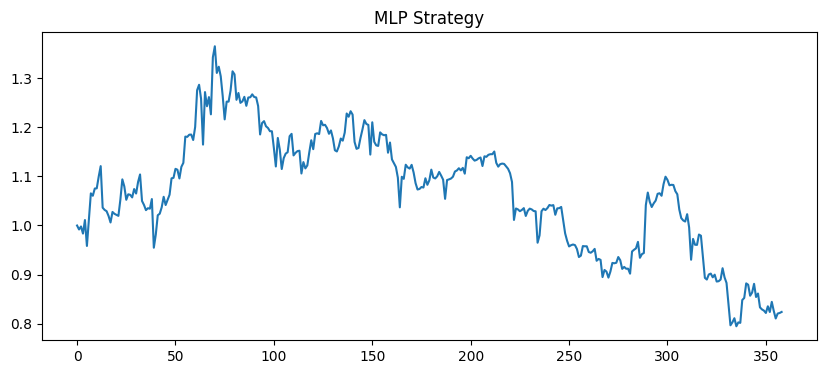

In [14]:
pred_mlp = mlp.predict(X_test)
cum_mlp = backtest(pred_mlp, y_test)

plt.figure(figsize=(10,4))
plt.plot(cum_mlp)
plt.title("MLP Strategy")
plt.show()

LSTM Strategy

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


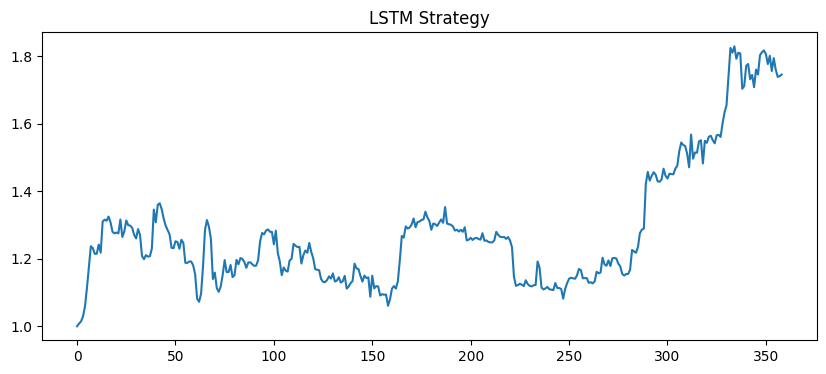

In [15]:
pred_lstm = lstm.predict(X_test_lstm)
cum_lstm = backtest(pred_lstm, y_test)

plt.figure(figsize=(10,4))
plt.plot(cum_lstm)
plt.title("LSTM Strategy")
plt.show()

CNN Strategy

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


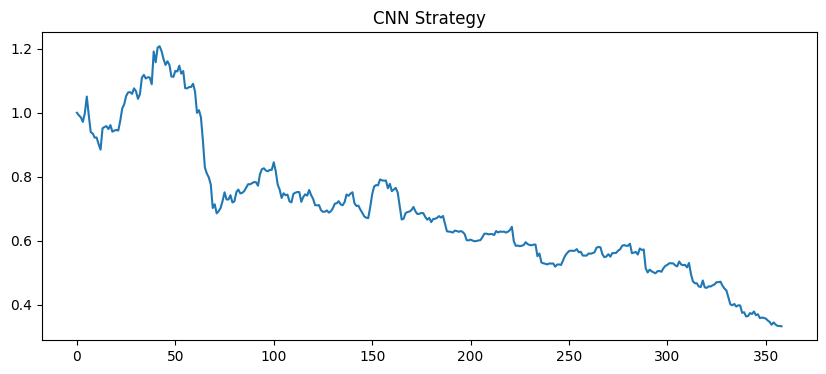

In [16]:
pred_cnn = cnn.predict(X_test_gaf)
cum_cnn = backtest(pred_cnn, y_test)

plt.figure(figsize=(10,4))
plt.plot(cum_cnn)
plt.title("CNN Strategy")
plt.show()

Step 2a - Walk Forward (500 / 500)

In [17]:
train_size = 500
test_size = 500

results = []

for start in range(0, len(X) - train_size - test_size, test_size):

    X_train_wf = X[start:start+train_size]
    y_train_wf = y[start:start+train_size]

    X_test_wf = X[start+train_size:start+train_size+test_size]
    y_test_wf = y[start+train_size:start+train_size+test_size]

    scaler = StandardScaler()
    X_train_wf = scaler.fit_transform(X_train_wf)
    X_test_wf = scaler.transform(X_test_wf)

    model = Sequential([
        Dense(32, activation="relu", input_shape=(X_train_wf.shape[1],)),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train_wf, y_train_wf, epochs=10, verbose=0)

    pred = model.predict(X_test_wf)
    results.extend(pred.flatten())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Step 2b - Walk Forward (500 / 100)

In [18]:
train_size = 500
test_size = 100

wf_returns = []

for start in range(0, len(X) - train_size - test_size, test_size):

    X_train_wf = X[start:start+train_size]
    y_train_wf = y[start:start+train_size]

    X_test_wf = X[start+train_size:start+train_size+test_size]
    y_test_wf = y[start+train_size:start+train_size+test_size]

    scaler = StandardScaler()
    X_train_wf = scaler.fit_transform(X_train_wf)
    X_test_wf = scaler.transform(X_test_wf)

    model = Sequential([
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train_wf, y_train_wf, epochs=10, verbose=0)

    pred = model.predict(X_test_wf)
    signals = np.where(pred > 0, 1, -1)
    strategy = signals.flatten() * y_test_wf
    wf_returns.extend(strategy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


Plot Walk Forward Performance

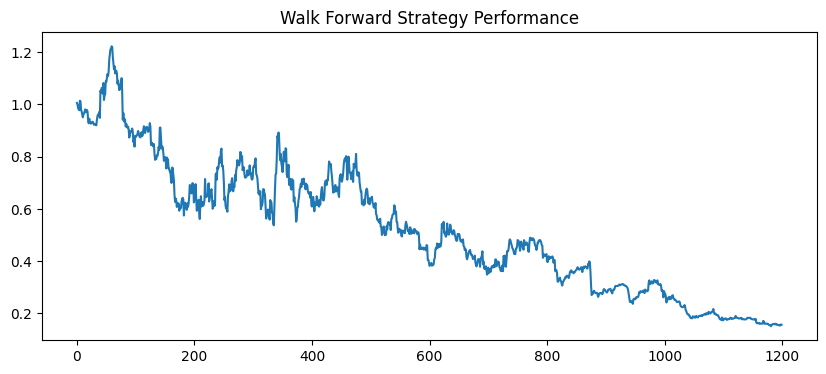

In [19]:
cum_wf = (1 + np.array(wf_returns)).cumprod()

plt.figure(figsize=(10,4))
plt.plot(cum_wf)
plt.title("Walk Forward Strategy Performance")
plt.show()



Step 3a: Purging and Non-Anchored Walk-Forward Method


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

def build_lstm_model(timesteps, features_count):
    model = Sequential([
        LSTM(50, input_shape=(timesteps, features_count)),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

Step 3b: Non-Anchored Walk-Forward (500 Train / 500 Test)

In [38]:


train_size = 500
test_size = 500
purge_window = 10

results_500_500 = []

features = X
target = y

# Convert to correct LSTM format if needed
if len(features.shape) == 2:
    features = features.reshape(features.shape[0], 1, features.shape[1])

print("Feature shape:", features.shape)

for i in range(0, len(features) - train_size - test_size - purge_window, test_size):

    X_train_f = features[i : i + train_size]
    y_train_f = target[i : i + train_size]

    test_start = i + train_size + purge_window

    X_test_f = features[test_start : test_start + test_size]
    y_test_f = target[test_start : test_start + test_size]

    model = build_lstm_model(X_train_f.shape[1], X_train_f.shape[2])

    model.fit(
        X_train_f,
        y_train_f,
        epochs=5,
        batch_size=32,
        verbose=0
    )

    mse = model.evaluate(X_test_f, y_test_f, verbose=0)
    results_500_500.append(mse)

print("Completed Step 3b:", len(results_500_500), "folds")

Feature shape: (1793, 1, 5)
Completed Step 3b: 2 folds


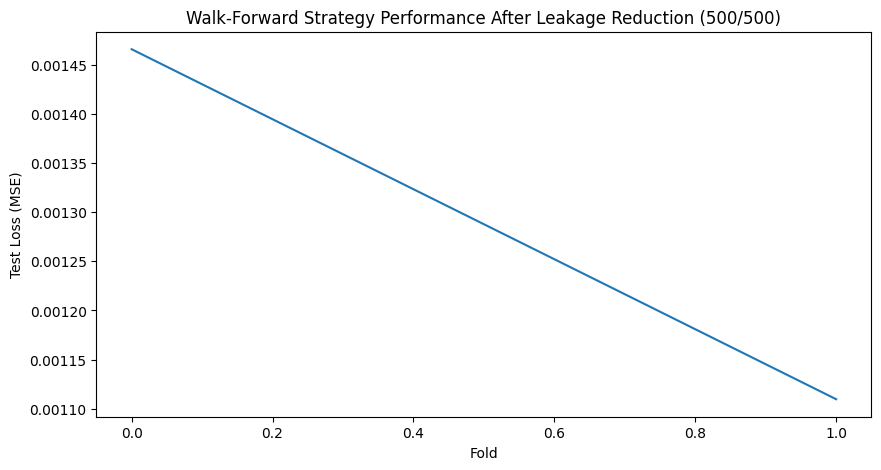

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(results_500_500)
plt.title("Walk-Forward Strategy Performance After Leakage Reduction (500/500)")
plt.xlabel("Fold")
plt.ylabel("Test Loss (MSE)")
plt.show()

Step 3c: Non-Anchored Walk-Forward (500 Train / 100 Test)

In [40]:


train_size = 500
test_size = 100
purge_window = 10

results_500_100 = []

features = X
target = y

# Ensure LSTM format
if len(features.shape) == 2:
    features = features.reshape(features.shape[0], 1, features.shape[1])

print("Feature shape:", features.shape)

for i in range(0, len(features) - train_size - test_size - purge_window, test_size):

    # Training data
    X_train_f = features[i : i + train_size]
    y_train_f = target[i : i + train_size]

    # Purge gap to reduce leakage
    test_start = i + train_size + purge_window

    # Testing data
    X_test_f = features[test_start : test_start + test_size]
    y_test_f = target[test_start : test_start + test_size]

    # Build fresh model
    model = build_lstm_model(X_train_f.shape[1], X_train_f.shape[2])

    model.fit(
        X_train_f,
        y_train_f,
        epochs=5,
        batch_size=32,
        verbose=0
    )

    mse = model.evaluate(X_test_f, y_test_f, verbose=0)
    results_500_100.append(mse)

print("Completed Step 3c:", len(results_500_100), "folds")

Feature shape: (1793, 1, 5)
Completed Step 3c: 12 folds


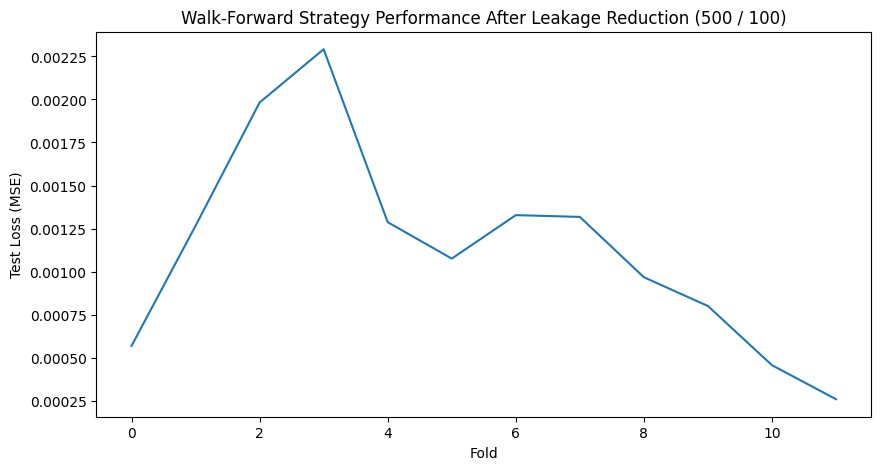

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(results_500_100)
plt.title("Walk-Forward Strategy Performance After Leakage Reduction (500 / 100)")
plt.xlabel("Fold")
plt.ylabel("Test Loss (MSE)")
plt.show()